# Rossmann Store Sales — Exploratory Data Analysis

**Objectif :** Comprendre les données, identifier les patterns de vente et préparer les insights pour le feature engineering.

**Dataset :** [Rossmann Store Sales — Kaggle](https://www.kaggle.com/c/rossmann-store-sales)

**Métrique cible :** RMSPE (Root Mean Square Percentage Error)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

DATASET = 'dataset/'

## 1. Chargement des données

In [2]:
train = pd.read_csv(DATASET + 'train.csv', parse_dates=['Date'], low_memory=False)
store = pd.read_csv(DATASET + 'store.csv')
test  = pd.read_csv(DATASET + 'test.csv',  parse_dates=['Date'], low_memory=False)

print(f'Train : {train.shape}  |  Store : {store.shape}  |  Test : {test.shape}')

Train : (1017209, 9)  |  Store : (1115, 10)  |  Test : (41088, 8)


In [3]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [4]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


## 2. Qualité des données

In [5]:
print('=== Train — valeurs manquantes ===')
print(train.isnull().sum())
print('\n=== Store — valeurs manquantes ===')
print(store.isnull().sum())

=== Train — valeurs manquantes ===
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

=== Store — valeurs manquantes ===
Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


In [6]:
train.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,2014-04-11 01:30:42.846061824,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
min,1.000000e+00,1.000000e+00,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,2013-08-17 00:00:00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,2014-04-02 00:00:00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,2014-12-12 00:00:00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,2015-07-31 00:00:00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00
std,3.219087e+02,1.997391e+00,NaN,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01


In [7]:
# Stores fermés vs ouverts
print('Open=0 (fermé) :', (train['Open'] == 0).sum())
print('Open=1 (ouvert) :', (train['Open'] == 1).sum())
print('Sales=0 quand Open=1 :', ((train['Open'] == 1) & (train['Sales'] == 0)).sum())

Open=0 (fermé) : 172817
Open=1 (ouvert) : 844392
Sales=0 quand Open=1 : 54


## 3. Distribution des ventes

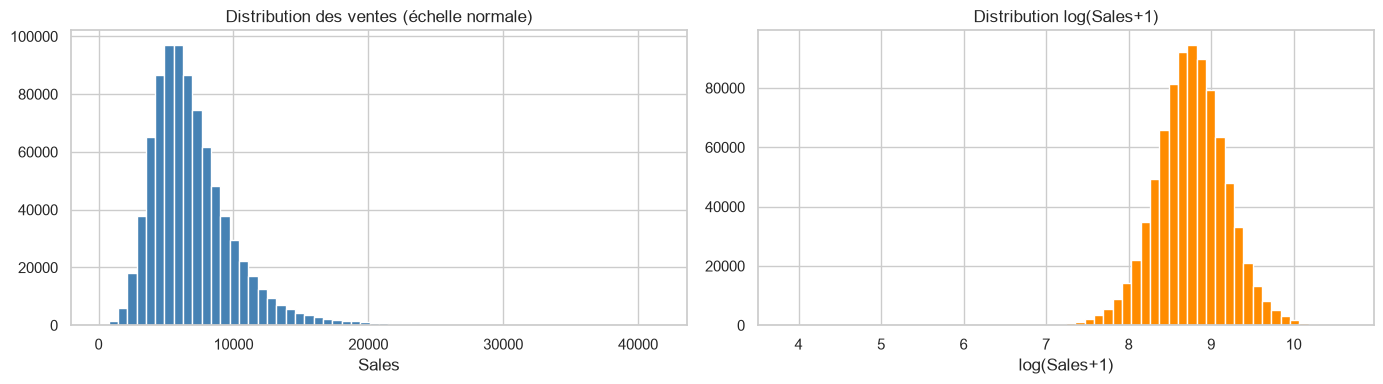

Skewness Sales : 1.595  |  log(Sales) : -0.109


In [8]:
df = train[(train['Open'] == 1) & (train['Sales'] > 0)].copy()
df = df.merge(store, on='Store', how='left')  # Promo2, StoreType, etc. disponibles dès ici

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Sales'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution des ventes (échelle normale)')
axes[0].set_xlabel('Sales')

axes[1].hist(np.log1p(df['Sales']), bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Distribution log(Sales+1)')
axes[1].set_xlabel('log(Sales+1)')

plt.tight_layout()
plt.show()
print(f'Skewness Sales : {df["Sales"].skew():.3f}  |  log(Sales) : {np.log1p(df["Sales"]).skew():.3f}')

## 4. Ventes dans le temps

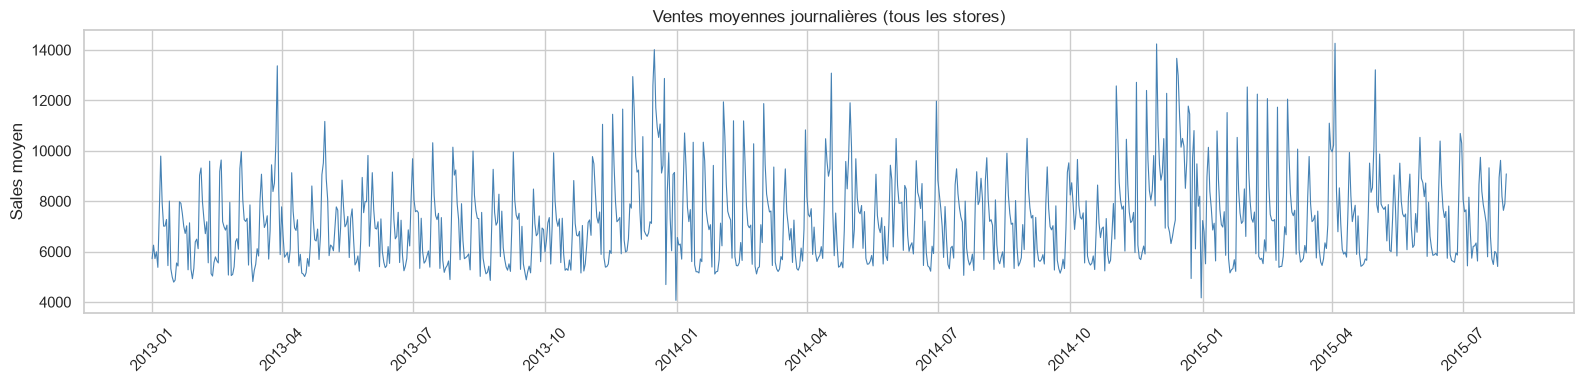

In [9]:
daily = df.groupby('Date')['Sales'].mean().reset_index()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(daily['Date'], daily['Sales'], linewidth=0.8, color='steelblue')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.set_title('Ventes moyennes journalières (tous les stores)')
ax.set_ylabel('Sales moyen')
plt.tight_layout()
plt.show()

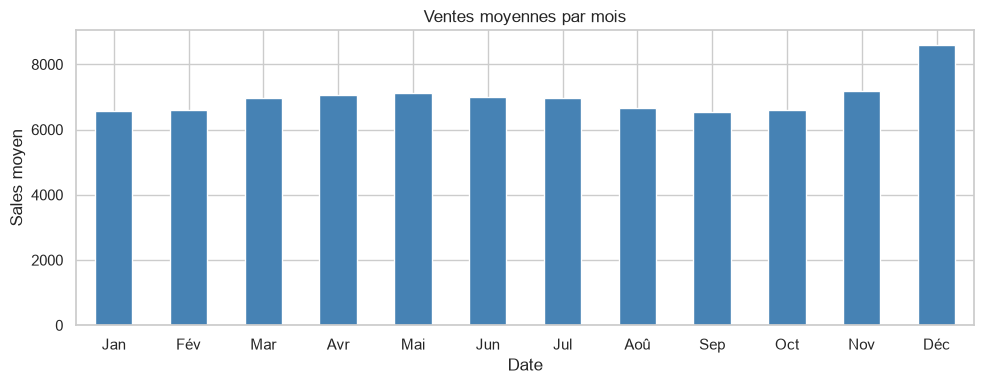

In [10]:
# Saisonnalité mensuelle
monthly = df.groupby(df['Date'].dt.month)['Sales'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xticklabels(['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc'], rotation=0)
ax.set_title('Ventes moyennes par mois')
ax.set_ylabel('Sales moyen')
plt.tight_layout()
plt.show()

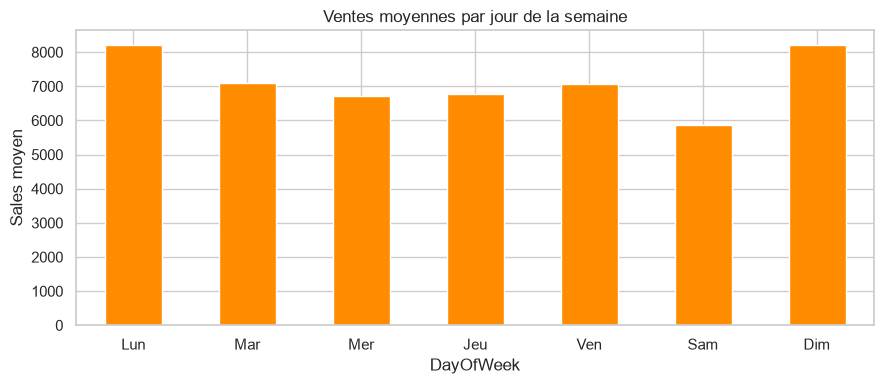

In [11]:
# Saisonnalité hebdomadaire
dow_map = {0:'Lun', 1:'Mar', 2:'Mer', 3:'Jeu', 4:'Ven', 5:'Sam', 6:'Dim'}
df['DayOfWeek_name'] = df['Date'].dt.dayofweek.map(dow_map)
weekly = df.groupby('DayOfWeek')['Sales'].mean()

fig, ax = plt.subplots(figsize=(9, 4))
weekly.plot(kind='bar', ax=ax, color='darkorange', edgecolor='white')
ax.set_xticklabels(list(dow_map.values()), rotation=0)
ax.set_title('Ventes moyennes par jour de la semaine')
ax.set_ylabel('Sales moyen')
plt.tight_layout()
plt.show()

## 5. Impact des promotions

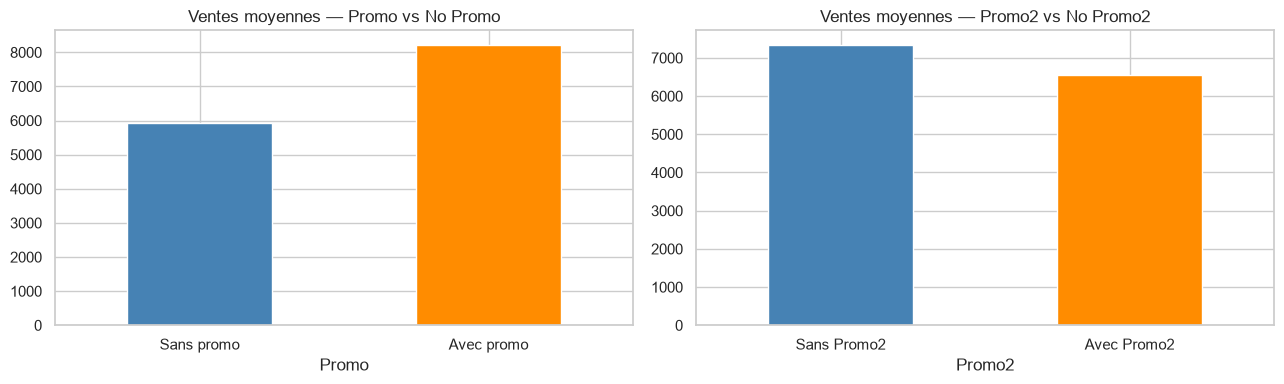

Lift Promo : +38.8%


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df.groupby('Promo')['Sales'].mean().plot(kind='bar', ax=axes[0], color=['steelblue','darkorange'], edgecolor='white')
axes[0].set_xticklabels(['Sans promo', 'Avec promo'], rotation=0)
axes[0].set_title('Ventes moyennes — Promo vs No Promo')

df.groupby('Promo2')['Sales'].mean().plot(kind='bar', ax=axes[1], color=['steelblue','darkorange'], edgecolor='white')
axes[1].set_xticklabels(['Sans Promo2', 'Avec Promo2'], rotation=0)
axes[1].set_title('Ventes moyennes — Promo2 vs No Promo2')

plt.tight_layout()
plt.show()

lift = df.groupby('Promo')['Sales'].mean()
print(f"Lift Promo : +{(lift[1]/lift[0]-1)*100:.1f}%")

## 6. Analyse par type de store

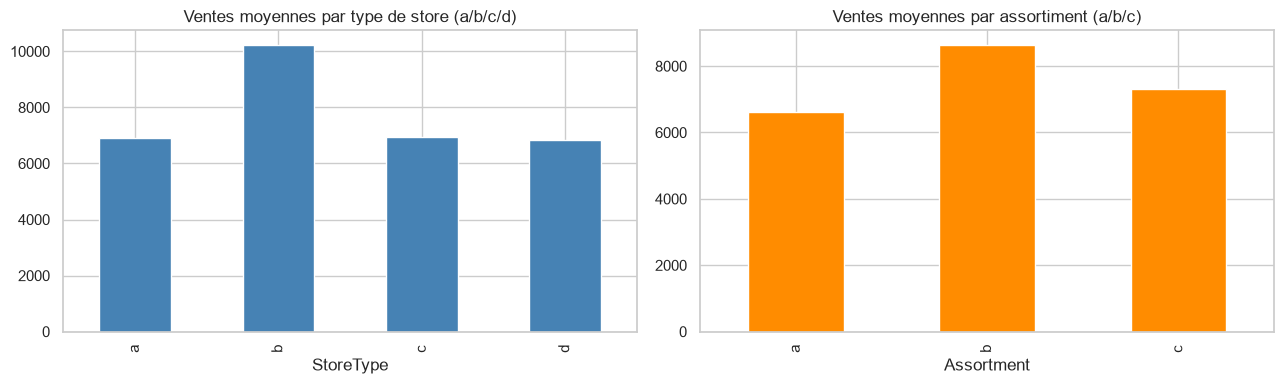

In [13]:
df2 = df  # store déjà mergé dans df (section 3)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df2.groupby('StoreType')['Sales'].mean().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Ventes moyennes par type de store (a/b/c/d)')
axes[0].set_xlabel('StoreType')

df2.groupby('Assortment')['Sales'].mean().plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Ventes moyennes par assortiment (a/b/c)')
axes[1].set_xlabel('Assortment')

plt.tight_layout()
plt.show()

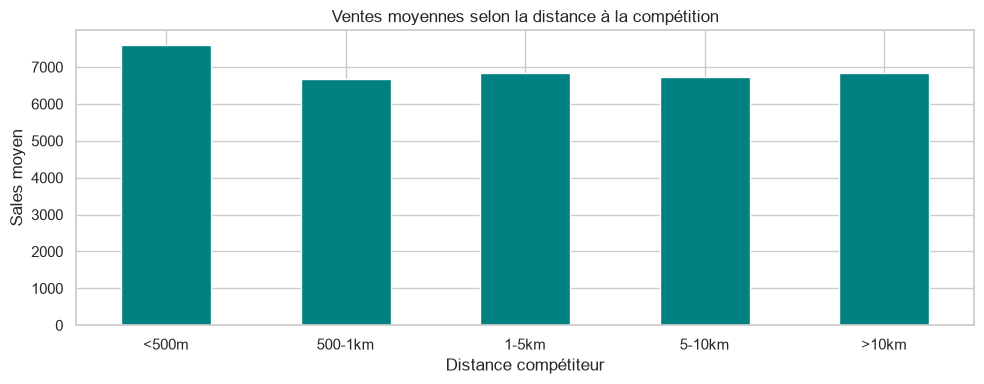

In [14]:
# Compétition vs ventes
df2['CompDist_bin'] = pd.cut(df2['CompetitionDistance'], bins=[0, 500, 1000, 5000, 10000, 100000], 
                              labels=['<500m','500-1km','1-5km','5-10km','>10km'])

fig, ax = plt.subplots(figsize=(10, 4))
df2.groupby('CompDist_bin')['Sales'].mean().plot(kind='bar', ax=ax, color='teal', edgecolor='white')
ax.set_title('Ventes moyennes selon la distance à la compétition')
ax.set_xlabel('Distance compétiteur')
ax.set_ylabel('Sales moyen')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Impact des jours fériés

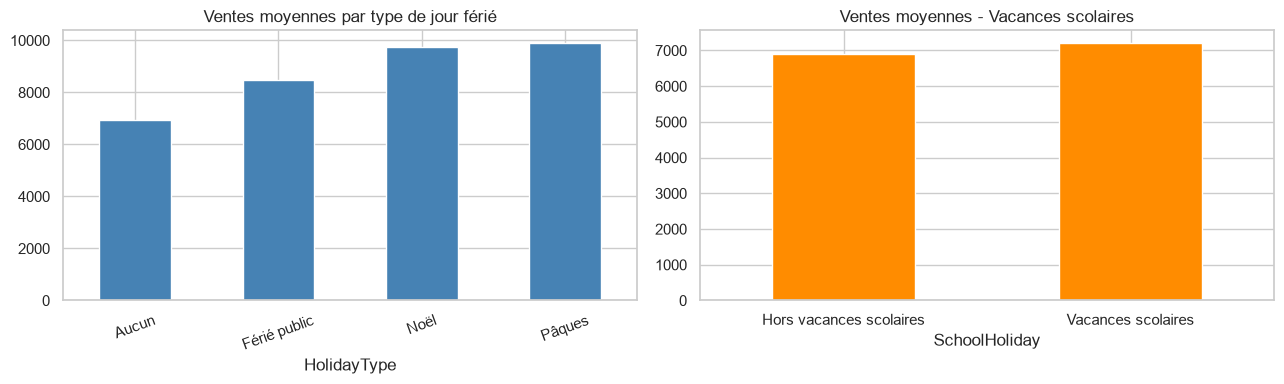

In [18]:
holiday_map = {'0': 'Aucun', 0: 'Aucun', 'a': 'Férié public', 'b': 'Pâques', 'c': 'Noël'}
df['HolidayType'] = df['StateHoliday'].map(holiday_map)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df.groupby('HolidayType')['Sales'].mean().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Ventes moyennes par type de jour férié')
plt.sca(axes[0]); plt.xticks(rotation=20)

df.groupby('SchoolHoliday')['Sales'].mean().plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_xticklabels(['Hors vacances scolaires', 'Vacances scolaires'], rotation=0)
axes[1].set_title('Ventes moyennes - Vacances scolaires')

plt.tight_layout()
plt.show()

## 8. Corrélation entre variables

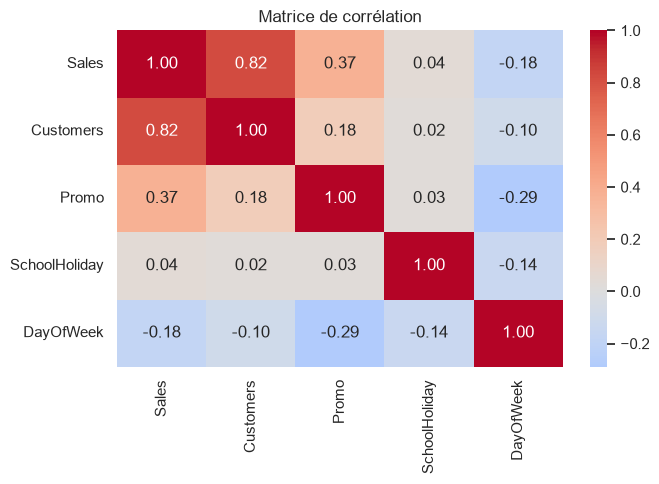

In [16]:
num_cols = ['Sales', 'Customers', 'Promo', 'SchoolHoliday', 'DayOfWeek']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Matrice de corrélation')
plt.tight_layout()
plt.show()

## 9. Top stores et variabilité

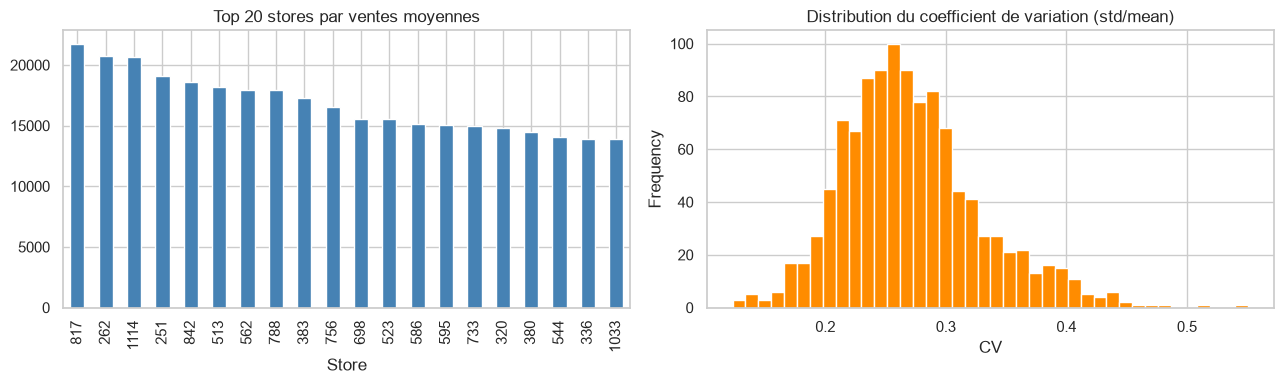

Nombre de stores : 1115
               mean          std        count           cv
count   1115.000000  1115.000000  1115.000000  1115.000000
mean    6934.631987  1845.570192   757.253812     0.271541
std     2383.982506   623.006028    63.848193     0.058409
min     2703.736573   575.952359   592.000000     0.123084
25%     5322.299969  1402.994203   776.000000     0.232560
50%     6589.948470  1773.281547   779.000000     0.263711
75%     7964.200644  2152.622961   782.000000     0.301064
max    21757.483418  4872.376644   942.000000     0.550837


In [17]:
store_perf = df.groupby('Store')['Sales'].agg(['mean','std','count']).sort_values('mean', ascending=False)
store_perf['cv'] = store_perf['std'] / store_perf['mean']  # coefficient de variation

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

store_perf['mean'].head(20).plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 20 stores par ventes moyennes')
axes[0].set_xlabel('Store')

store_perf['cv'].plot(kind='hist', bins=40, ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Distribution du coefficient de variation (std/mean)')
axes[1].set_xlabel('CV')

plt.tight_layout()
plt.show()

print(f"Nombre de stores : {store_perf.shape[0]}")
print(store_perf.describe())

## 10. Résumé des insights

| Insight | Impact sur le modèle |
|---|---|
| Les ventes suivent une loi log-normale → prédire `log(Sales)` | Transformation cible |
| Pic en décembre (Noël) + creux en janvier | Features mois/semaine |
| Lundi = jour le plus fort, dimanche = fermé | Feature DayOfWeek |
| Promo augmente les ventes de ~20% | Feature Promo |
| Store type 'b' a les ventes les plus élevées | Encoding StoreType |
| Plus le concurrent est loin, plus les ventes sont élevées | Feature CompetitionDistance |
| Vacances scolaires impact neutre à légèrement positif | Feature SchoolHoliday |